In [1]:
import jax
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = np.load('/mnt/home/abhagava/Neural-Spectral-Methods/log/cw.X10/fixed_scaling_prelim/uhat.npy')

In [ ]:
# THIS DATASET HAS NOW BEEN MOVED INTO THE "NOTEBOOKS" FOLDER
true_data = np.load('/mnt/home/abhagava/Neural-Spectral-Methods/src/pde/curledwake/_u_full.npy')

In [83]:
data[0][48][:, :, 0].shape

(129, 129)

#### Gibbs Oscillation Analysis

In [84]:
import numpy as np
import matplotlib.pyplot as plt

# u: 2D array for a final frame
def plot_zoom(u, center=None, radius=40):
    ny, nx = u.shape
    if center is None:
        # pick location of largest gradient magnitude
        gy, gx = np.gradient(u)
        center = np.unravel_index(np.argmax(np.sqrt(gy**2 + gx**2)), u.shape)
    y0, x0 = center
    y1, y2 = max(0,y0-radius), min(ny,y0+radius)
    x1, x2 = max(0,x0-radius), min(nx,x0+radius)
    plt.figure(figsize=(6,5))
    plt.imshow(u[y1:y2,x1:x2], origin='lower', interpolation='nearest', aspect='auto')
    plt.colorbar()
    plt.title("Zoom near strongest gradient — look for ringing")
    plt.show()


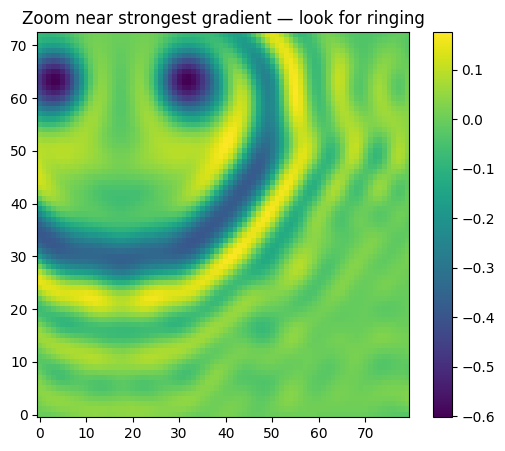

In [85]:
plot_zoom(data[0][50][:, :, 0])

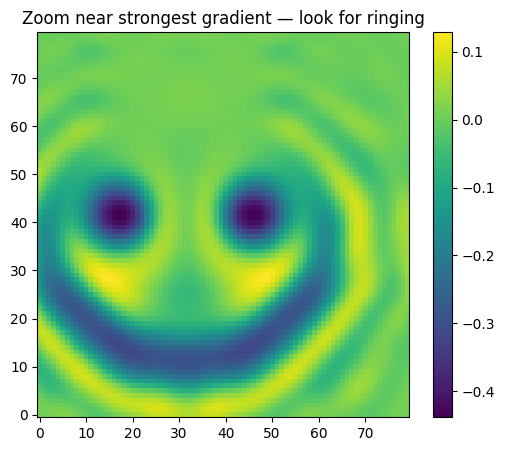

In [86]:
plot_zoom(data[0][40][:, :, 0])

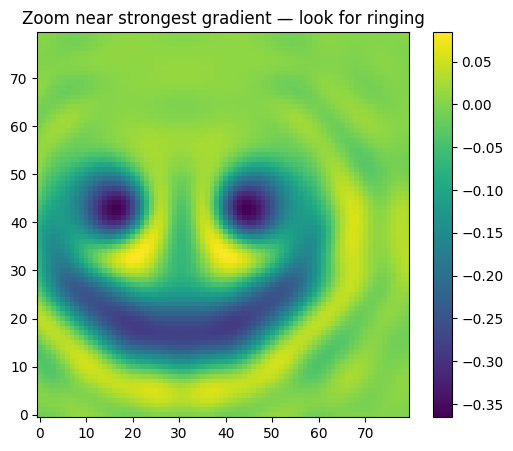

In [87]:
plot_zoom(data[0][30][:, :, 0])

Compare a reconstructed ground-truth image with the prediction at time step 50

In [88]:
f_transform = np.fft.fft2(true_data[0][50][:, :, 0])
f_transform_shifted = np.fft.fftshift(f_transform)

rows, cols = true_data[0][50][:, :, 0].shape
crow, ccol = rows // 2, cols // 2

# Create a mask to retain a central region (low frequencies)
num_modes = 13                 # desired number of modes per dimension
radius = (num_modes - 1) // 2  # Adjust for desired level of approximation
mask = np.zeros(f_transform_shifted.shape, dtype=bool)
mask[crow - radius:crow + radius, ccol - radius:ccol + radius] = True

# Apply the mask
f_transform_filtered = f_transform_shifted * mask
f_transform_unshifted = np.fft.ifftshift(f_transform_filtered)
approximated_image = np.fft.ifft2(f_transform_unshifted)
approximated_image = np.abs(approximated_image) # Take magnitude as it's an image

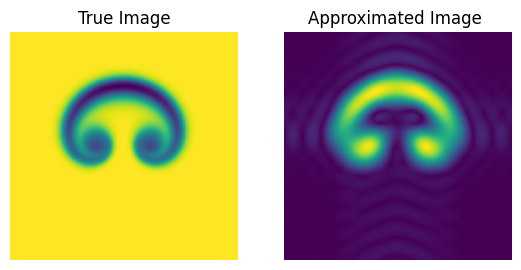

In [89]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1)
plt.imshow(true_data[0][50][:, :, 0])
plt.title('True Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(approximated_image)
plt.title(f'Approximated Image ')
plt.axis('off')
plt.show()

#### Aliasing Analysis

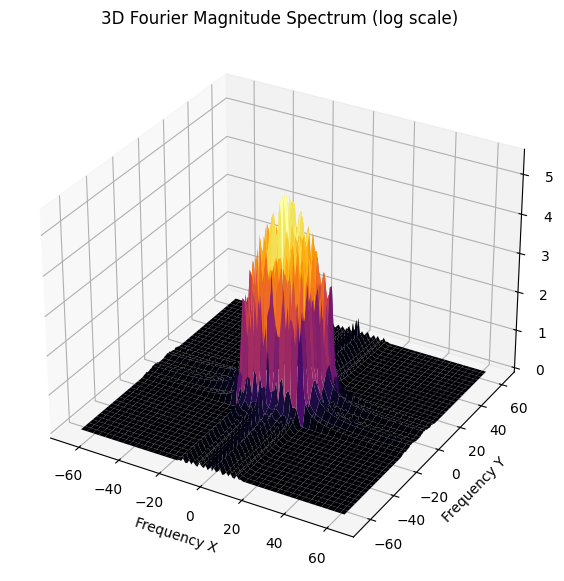

In [90]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Compute 2D FFT
fourier_2d = np.fft.fftn(data[0][50][:, :, 0])
fourier_shifted = np.fft.fftshift(fourier_2d)
magnitude_spectrum = np.abs(fourier_shifted)

# Coordinates
nx, ny = magnitude_spectrum.shape
x = np.arange(-nx//2, nx//2)
y = np.arange(-ny//2, ny//2)
X, Y = np.meshgrid(x, y)

# Plot as 3D surface
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, np.log1p(magnitude_spectrum), cmap='inferno')

ax.set_title("3D Fourier Magnitude Spectrum (log scale)")
ax.set_xlabel("Frequency X")
ax.set_ylabel("Frequency Y")
ax.set_zlabel("Magnitude (log)")

plt.show()


In [91]:
import scipy.stats as stats

Text(0.5, 1.0, 'Radial power spectrum (not de-aliased)')

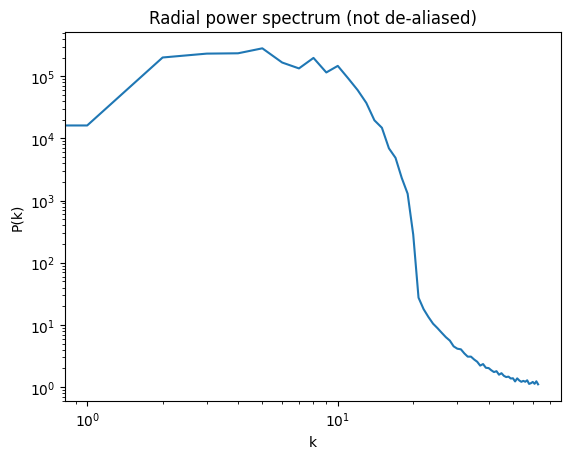

In [92]:
fourier_image = np.fft.fftn(data[0][50][:, :, 0])
fourier_amplitudes = np.abs(fourier_image)**2
npix = data[0][50][:, :, 0].shape[0]
kfreq = np.fft.fftfreq(npix) * npix
kfreq2D = np.meshgrid(kfreq, kfreq)
knrm = np.sqrt(kfreq2D[0]**2 + kfreq2D[1]**2)
knrm = knrm.flatten()
fourier_amplitudes = fourier_amplitudes.flatten()
kbins = np.arange(0.5, npix//2+1, 1.)
kvals = 0.5 * (kbins[1:] + kbins[:-1])
Abins, _, _ = stats.binned_statistic(knrm, fourier_amplitudes,
                                     statistic = "mean",
                                     bins = kbins)
Abins *= np.pi * (kbins[1:]**2 - kbins[:-1]**2)
plt.loglog(Abins)
plt.xlabel('k')
plt.ylabel('P(k)')
plt.title('Radial power spectrum (not de-aliased)')

In [93]:
# dealias the predicted image
def compute_dealiased_power_spectrum(image_data):
    """
    Compute radial power spectrum with 2/3 rule de-aliasing
    """
    # Compute 2D FFT
    fourier_image = np.fft.fftn(image_data)
    fourier_amplitudes = np.abs(fourier_image)**2
    
    npix = image_data.shape[0]
    
    # Apply 2/3 rule: zero out modes beyond 2/3 of Nyquist frequency
    # Create a mask for the central 2/3 of k-space
    kmax_dealiased = npix // 3  # 2/3 of npix//2 (Nyquist)
    
    # Create coordinate arrays
    kfreq = np.fft.fftfreq(npix) * npix
    kfreq2D = np.meshgrid(kfreq, kfreq)
    knrm = np.sqrt(kfreq2D[0]**2 + kfreq2D[1]**2)
    
    # Apply de-aliasing mask
    mask = knrm <= kmax_dealiased
    fourier_amplitudes_dealiased = fourier_amplitudes * mask
    
    # Flatten for radial binning
    knrm_flat = knrm.flatten()
    fourier_amplitudes_flat = fourier_amplitudes_dealiased.flatten()
    
    # Only consider modes within the de-aliased range
    valid_modes = knrm_flat <= kmax_dealiased
    knrm_valid = knrm_flat[valid_modes]
    fourier_amplitudes_valid = fourier_amplitudes_flat[valid_modes]
    
    # Create radial bins up to the de-aliased limit
    kbins = np.arange(0.5, kmax_dealiased + 1, 1.)
    kvals = 0.5 * (kbins[1:] + kbins[:-1])
    
    # Radially bin the power
    Abins, _, _ = stats.binned_statistic(knrm_valid, fourier_amplitudes_valid,
                                       statistic="mean", bins=kbins)
    
    # Apply normalization (area of annulus)
    Abins *= np.pi * (kbins[1:]**2 - kbins[:-1]**2)
    
    return kvals, Abins, kmax_dealiased

def plot_comparison(image_data):
    """
    Plot both original and de-aliased power spectra for comparison
    """
    # Original calculation (your code)
    fourier_image = np.fft.fftn(image_data)
    fourier_amplitudes = np.abs(fourier_image)**2
    npix = image_data.shape[0]
    kfreq = np.fft.fftfreq(npix) * npix
    kfreq2D = np.meshgrid(kfreq, kfreq)
    knrm = np.sqrt(kfreq2D[0]**2 + kfreq2D[1]**2)
    knrm = knrm.flatten()
    fourier_amplitudes = fourier_amplitudes.flatten()
    kbins_orig = np.arange(0.5, npix//2+1, 1.)
    kvals_orig = 0.5 * (kbins_orig[1:] + kbins_orig[:-1])
    Abins_orig, _, _ = stats.binned_statistic(knrm, fourier_amplitudes,
                                            statistic="mean", bins=kbins_orig)
    Abins_orig *= np.pi * (kbins_orig[1:]**2 - kbins_orig[:-1]**2)
    
    # De-aliased calculation
    kvals_dealiased, Abins_dealiased, kmax_dealiased = compute_dealiased_power_spectrum(image_data)
    
    # Plot comparison
    plt.figure(figsize=(10, 6))
    
    plt.loglog(kvals_orig, Abins_orig, 'b-', alpha=0.7, label='Original (aliased)')
    plt.loglog(kvals_dealiased, Abins_dealiased, 'r-', linewidth=2, label='De-aliased (2/3 rule)')
    plt.axvline(x=kmax_dealiased, color='k', linestyle='--', alpha=0.5, 
                label=f'2/3 cutoff (k={kmax_dealiased})')
    
    plt.xlabel('k')
    plt.ylabel('P(k)')
    plt.title('Radial Power Spectrum: Original vs De-aliased')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    print(f"Original spectrum extends to k = {npix//2}")
    print(f"De-aliased spectrum extends to k = {kmax_dealiased}")
    print(f"Reduction factor: {kmax_dealiased/(npix//2):.3f}")
    
    return kvals_dealiased, Abins_dealiased

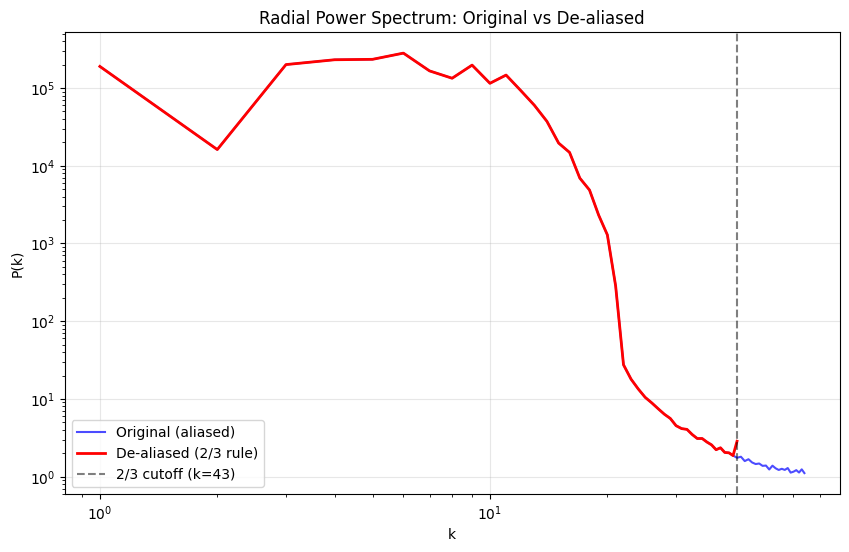

Original spectrum extends to k = 64
De-aliased spectrum extends to k = 43
Reduction factor: 0.672


(array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
        14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25., 26.,
        27., 28., 29., 30., 31., 32., 33., 34., 35., 36., 37., 38., 39.,
        40., 41., 42., 43.]),
 array([1.89563143e+05, 1.61488194e+04, 2.00160733e+05, 2.31052624e+05,
        2.33848611e+05, 2.81106517e+05, 1.66076771e+05, 1.33590255e+05,
        1.97046137e+05, 1.14989672e+05, 1.46718997e+05, 9.25629632e+04,
        5.99446722e+04, 3.72137917e+04, 1.95675821e+04, 1.48309437e+04,
        6.92418793e+03, 4.86997446e+03, 2.31197996e+03, 1.28995541e+03,
        2.84682339e+02, 2.74831493e+01, 1.79653489e+01, 1.34265723e+01,
        1.04781516e+01, 8.88255108e+00, 7.46784266e+00, 6.35504336e+00,
        5.60190026e+00, 4.52569730e+00, 4.15041124e+00, 4.05345176e+00,
        3.48332580e+00, 3.09295352e+00, 3.09402284e+00, 2.78427991e+00,
        2.56149390e+00, 2.21950705e+00, 2.34967654e+00, 2.04657182e+00,
        2.02451329e+00, 1.86528

In [94]:
plot_comparison(data[0][50][:, :, 0])

In [95]:
def plot_images_comparison(image_data):
    """
    Plot original image vs de-aliased image side by side
    """
    # Original image
    original_image = image_data
    
    # Create de-aliased image by filtering in Fourier space
    fourier_image = np.fft.fftn(image_data)
    npix = image_data.shape[0]
    kmax_dealiased = npix // 3
    
    # Create the 2/3 rule mask
    kfreq = np.fft.fftfreq(npix) * npix
    kfreq2D = np.meshgrid(kfreq, kfreq)
    knrm = np.sqrt(kfreq2D[0]**2 + kfreq2D[1]**2)
    mask = knrm <= kmax_dealiased
    
    # Apply mask and inverse transform
    fourier_dealiased = fourier_image * mask
    dealiased_image = np.real(np.fft.ifftn(fourier_dealiased))
    
    # Create side-by-side plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Use same colorscale for both images
    vmin = min(original_image.min(), dealiased_image.min())
    vmax = max(original_image.max(), dealiased_image.max())
    
    # Original image
    im1 = ax1.imshow(original_image, origin='lower', vmin=vmin, vmax=vmax, cmap='viridis')
    ax1.set_title('Original Image')
    ax1.set_xlabel('Pixel')
    ax1.set_ylabel('Pixel')
    plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
    
    # De-aliased image
    im2 = ax2.imshow(dealiased_image, origin='lower', vmin=vmin, vmax=vmax, cmap='viridis')
    ax2.set_title('De-aliased Image (2/3 rule)')
    ax2.set_xlabel('Pixel')
    ax2.set_ylabel('Pixel')
    plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.show()
    
    # Print some statistics
    diff_image = original_image - dealiased_image
    print(f"Original image range: [{original_image.min():.3f}, {original_image.max():.3f}]")
    print(f"De-aliased image range: [{dealiased_image.min():.3f}, {dealiased_image.max():.3f}]")
    print(f"RMS difference: {np.sqrt(np.mean(diff_image**2)):.3f}")
    print(f"Max absolute difference: {np.abs(diff_image).max():.3f}")
    print(f"Relative RMS difference: {np.sqrt(np.mean(diff_image**2))/np.std(original_image):.3f}")
    
    return dealiased_image

def plot_difference_image(image_data):
    """
    Plot the difference between original and de-aliased images
    """
    original_image = image_data
    
    # Create de-aliased image
    fourier_image = np.fft.fftn(image_data)
    npix = image_data.shape[0]
    kmax_dealiased = npix // 3
    
    kfreq = np.fft.fftfreq(npix) * npix
    kfreq2D = np.meshgrid(kfreq, kfreq)
    knrm = np.sqrt(kfreq2D[0]**2 + kfreq2D[1]**2)
    mask = knrm <= kmax_dealiased
    
    fourier_dealiased = fourier_image * mask
    dealiased_image = np.real(np.fft.ifftn(fourier_dealiased))
    
    # Difference image
    diff_image = original_image - dealiased_image
    
    plt.figure(figsize=(8, 6))
    plt.imshow(diff_image, origin='lower', cmap='RdBu_r')
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.title('Difference: Original - De-aliased')
    plt.xlabel('Pixel')
    plt.ylabel('Pixel')
    plt.show()
    
    return diff_image

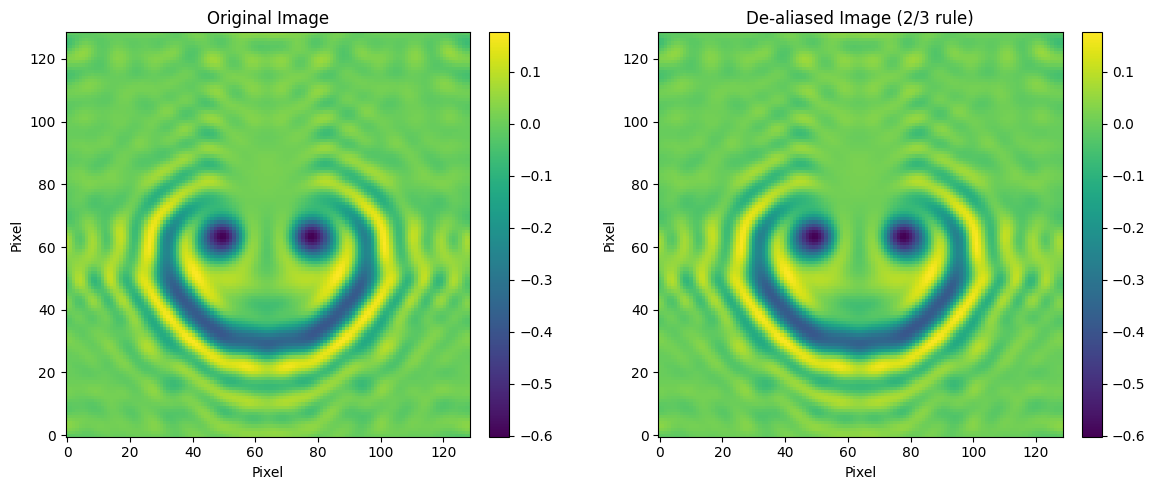

Original image range: [-0.602, 0.176]
De-aliased image range: [-0.602, 0.175]
RMS difference: 0.000
Max absolute difference: 0.005
Relative RMS difference: 0.004


array([[-0.0143633 , -0.01346053, -0.01288622, ..., -0.01918425,
        -0.01665763, -0.01509685],
       [ 0.00450997,  0.00373488,  0.00121841, ..., -0.00064214,
         0.00272935,  0.00424834],
       [ 0.02900375,  0.02625386,  0.02037814, ...,  0.02391378,
         0.02803257,  0.02944513],
       ...,
       [-0.05989437, -0.05271106, -0.03983699, ..., -0.06027745,
        -0.06299002, -0.06209445],
       [-0.04070005, -0.03671915, -0.02983496, ..., -0.04375127,
        -0.04349317, -0.04203445],
       [-0.02384935, -0.02203403, -0.01935969, ..., -0.02831166,
        -0.02631158, -0.02465993]])

In [96]:
plot_images_comparison(data[0][50][:, :, 0])

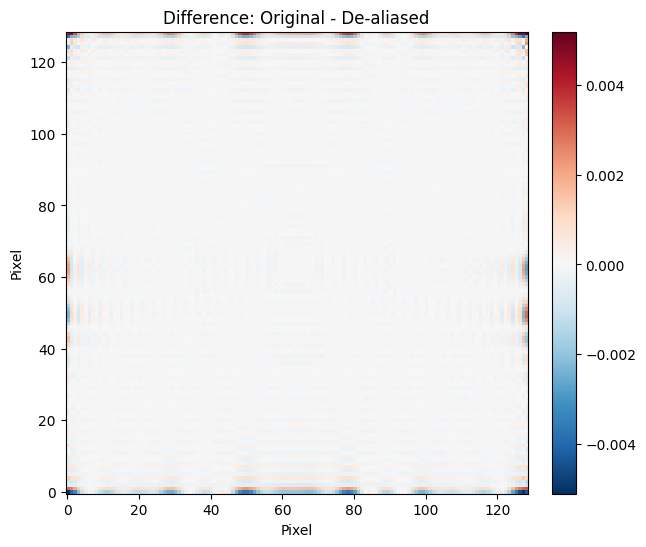

array([[-5.10914010e-03, -4.01838946e-03, -3.26246322e-03, ...,
        -4.49174595e-03, -5.04756732e-03, -4.37558661e-03],
       [ 2.87910914e-03,  2.70700170e-03,  1.97919953e-03, ...,
         2.72929992e-03,  3.07164863e-03,  3.14074513e-03],
       [-5.11332046e-04, -5.29460194e-04, -5.20723876e-04, ...,
        -6.50319578e-04, -4.84765214e-04, -9.52719256e-04],
       ...,
       [-2.75047735e-04,  1.16637270e-03,  5.75396004e-04, ...,
         9.56231988e-04, -3.24748449e-05,  1.92503718e-03],
       [-3.76952856e-03, -2.30110337e-03, -2.25041206e-03, ...,
        -2.73241321e-03, -3.67694326e-03, -2.43512273e-03],
       [ 4.37691060e-03,  4.55510704e-03,  3.21100870e-03, ...,
         4.63567120e-03,  4.60638583e-03,  5.18749013e-03]])

In [97]:
plot_difference_image(data[0][50][:, :, 0])

#### Lanczos Sigma Factor

In [6]:
original_image = true_data[0][50][:, :, 0]
predicted_image = data[0][50][:, :, 0]

In [ ]:
# ABOLUTE ERROR OF EACH FRAME BEFORE FILTERING 
# ABSOLUTE ERROR OF EACH FRAME AFTER FILTERING 
# RIGHT NOW MANUAL FINETUNING, COULD POTENTIALLY MAKE THIS A TRAINABLE CORRECTION STEP 

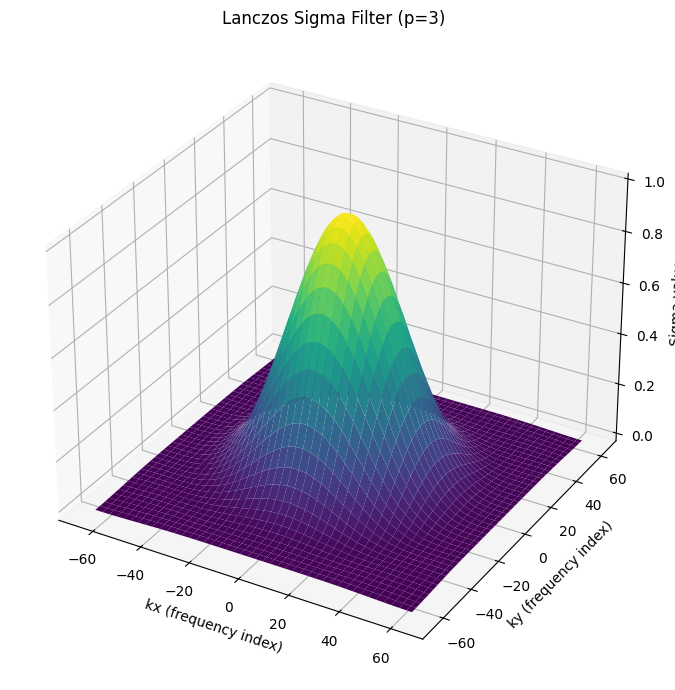

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D plotting

def lanczos_sigma_filter(shape, p):
    rows, cols = shape
    ky = np.arange(-rows//2, rows//2)
    kx = np.arange(-cols//2, cols//2)
    KX, KY = np.meshgrid(kx, ky)
    R = np.sqrt(KX**2 + KY**2)
    N = min(rows, cols) // 2
    sigma = np.sinc(R / N) ** p
    return sigma

# Generate filter
shape = (129, 129)
p = 3
sigma = lanczos_sigma_filter(shape, p)

# Create coordinate grid (for plotting axes)
rows, cols = shape
kx = np.arange(-cols//2, cols//2)
ky = np.arange(-rows//2, rows//2)
KX, KY = np.meshgrid(kx, ky)

# Plot 3D surface
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(KX, KY, sigma, cmap='viridis', edgecolor='none')

ax.set_title(f"Lanczos Sigma Filter (p={p})")
ax.set_xlabel("kx (frequency index)")
ax.set_ylabel("ky (frequency index)")
ax.set_zlabel("Sigma value")
plt.tight_layout()
plt.show()


In [6]:
pred = data[0][50][:, :, 0]

# FFT and shift zero-frequency to center
f_pred = np.fft.fftshift(np.fft.fft2(pred))

# Create and apply Lanczos sigma mask
sigma_mask = lanczos_sigma_filter(pred.shape, 64)
f_pred_filtered = f_pred * sigma_mask

# Inverse FFT to get filtered prediction
pred_filtered = np.real(np.fft.ifft2(np.fft.ifftshift(f_pred_filtered)))


/mnt/home/abhagava/.local/lib/python3.10/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


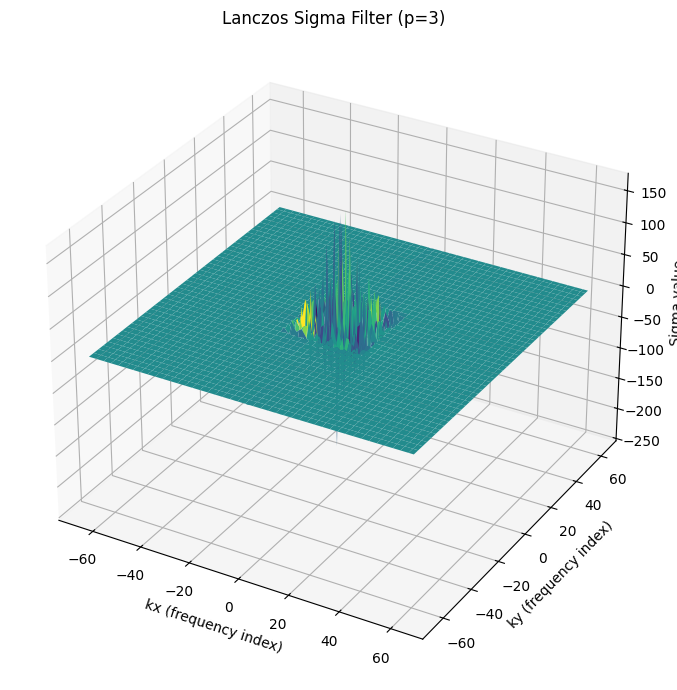

In [7]:
# Plot 3D surface
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(KX, KY, f_pred, cmap='viridis', edgecolor='none')

ax.set_title(f"Lanczos Sigma Filter (p={p})")
ax.set_xlabel("kx (frequency index)")
ax.set_ylabel("ky (frequency index)")
ax.set_zlabel("Sigma value")
plt.tight_layout()
plt.show()

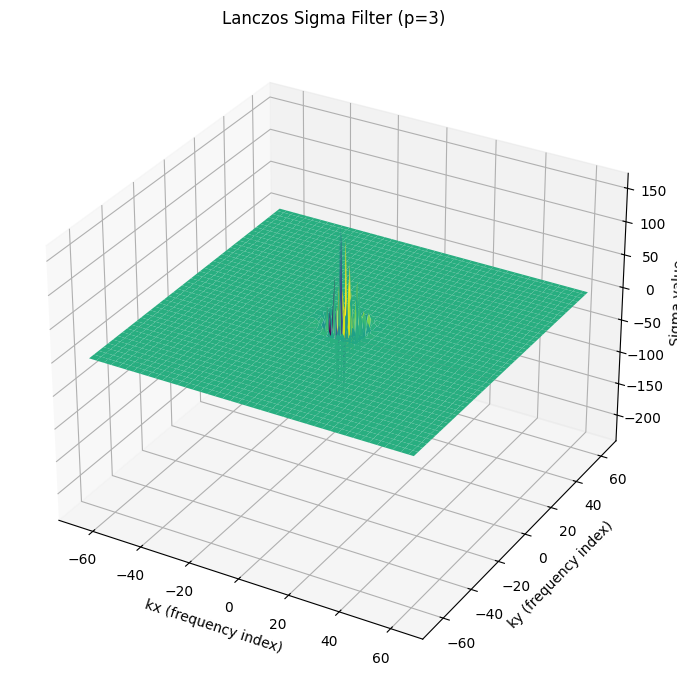

In [8]:
# Plot 3D surface
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(KX, KY, f_pred_filtered, cmap='viridis', edgecolor='none')

ax.set_title(f"Lanczos Sigma Filter (p={p})")
ax.set_xlabel("kx (frequency index)")
ax.set_ylabel("ky (frequency index)")
ax.set_zlabel("Sigma value")
plt.tight_layout()
plt.show()

auto cutoff radius (pct 0.995): 14


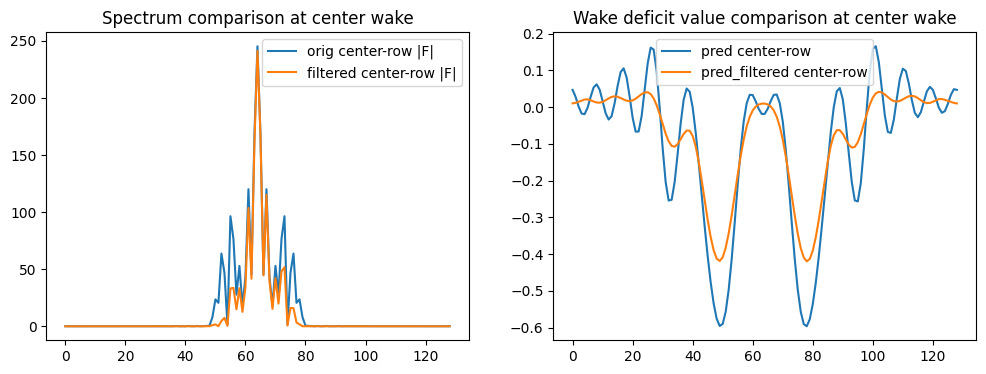

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal.windows import lanczos

# --- helper: radial profile ---
def radial_profile(image):
    """Return radius coords and mean of image in annuli around center."""
    rows, cols = image.shape
    cy, cx = rows//2, cols//2
    y = np.arange(rows) - cy
    x = np.arange(cols) - cx
    X, Y = np.meshgrid(x, y)
    R = np.sqrt(X**2 + Y**2)
    R_flat = R.ravel()
    img_flat = image.ravel()
    # integer radii
    r_int = np.round(R_flat).astype(int)
    max_r = int(R.max())
    t = np.bincount(r_int, weights=img_flat, minlength=max_r+1)
    n = np.bincount(r_int, minlength=max_r+1)
    with np.errstate(invalid='ignore', divide='ignore'):
        radial_mean = t / np.maximum(n, 1)
    radii = np.arange(len(radial_mean))
    return radii, radial_mean

# --- data (replace these with your arrays) ---
pred = data[0][50][:, :, 0]
original = true_data[0][50][:, :, 0]

# --- compute FFT and power spectrum ---
F_pred = np.fft.fftshift(np.fft.fft2(pred))
power = np.abs(F_pred)**2

# radial profile of power
radii, power_profile = radial_profile(power)

# choose cutoff automatically (options below)
# Option: choose radius where cumulative power reaches X% (e.g. 99%)
cum_power = np.cumsum(power_profile)
cum_power_norm = cum_power / cum_power[-1]
# desired percentile (tune this: 0.99, 0.995, 0.999)
pct = 0.995
cutoff_radius_auto = int(np.searchsorted(cum_power_norm, pct))
print("auto cutoff radius (pct {:.3f}):".format(pct), cutoff_radius_auto)

# --- build a Lanczos sigma mask using the cutoff radius ---
def lanczos_sigma_mask(shape, cutoff, p=1, normalize_dc=True):
    rows, cols = shape
    ky = np.arange(-rows//2, rows//2)
    kx = np.arange(-cols//2, cols//2)
    KX, KY = np.meshgrid(kx, ky)
    R = np.sqrt(KX**2 + KY**2)
    # normalized argument to sinc
    with np.errstate(divide='ignore', invalid='ignore'):
        mask = np.sinc(R / cutoff) ** p
    # replace nan at center with 1.0
    mask[np.isnan(mask)] = 1.0
    if normalize_dc:
        # scale mask so DC is 1 (should already be near 1)
        mask = mask / np.max(mask)
    return mask

# Let user optionally override cutoff; here use the auto value
cutoff = cutoff_radius_auto        # try changing this manually
p = 1                              # exponent: 1 (gentle), 2 stronger
mask = lanczos_sigma_mask(pred.shape, cutoff, p=p)

# Apply mask in Fourier domain
F_filtered = F_pred * mask
pred_filtered = np.real(np.fft.ifft2(np.fft.ifftshift(F_filtered)))

# --- also show 1D center cross-section to compare narrow peaks ---
center_row = pred.shape[0]//2
fig2, ax = plt.subplots(1,2,figsize=(12,4))
ax[0].plot(np.abs(F_pred[center_row,:]), label='orig center-row |F|')
ax[0].plot(np.abs(F_filtered[center_row,:]), label='filtered center-row |F|')
ax[0].set_title('Spectrum comparison at center wake')
ax[0].legend()
ax[1].plot(np.real(pred[center_row,:]), label='pred center-row')
ax[1].plot(np.real(pred_filtered[center_row,:]), label='pred_filtered center-row')
ax[1].set_title('Wake deficit value comparison at center wake')
ax[1].legend()
plt.show()


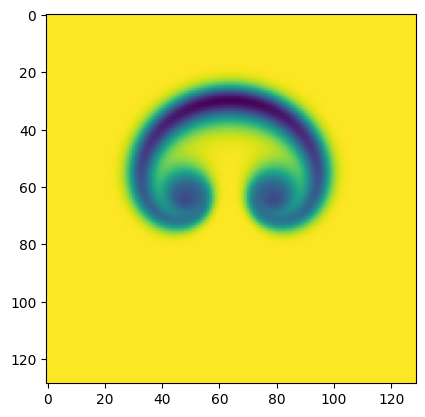

In [9]:
plt.imshow(true_data[0][50][:, :, 0])

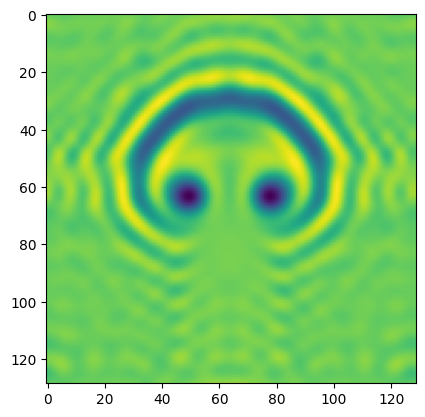

In [10]:
plt.imshow(pred)

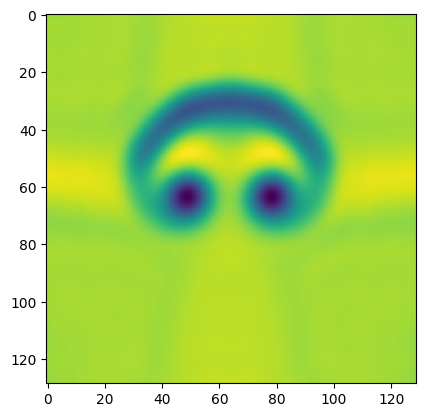

In [11]:
plt.imshow(pred_filtered)

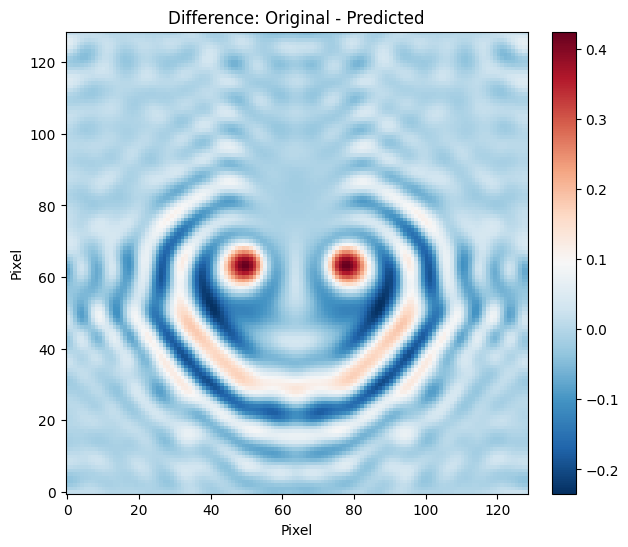

In [27]:
original_image = true_data[0][50][:, :, 0]
predicted_image = data[0][50][:, :, 0]
diff_image1 = original_image - predicted_image
    
plt.figure(figsize=(8, 6))
plt.imshow(diff_image1, origin='lower', cmap='RdBu_r', vmax=diff_image1.max(), vmin=diff_image1.min())
plt.colorbar(fraction=0.046, pad=0.04)
plt.title('Difference: Original - Predicted')
plt.xlabel('Pixel')
plt.ylabel('Pixel')
plt.show()

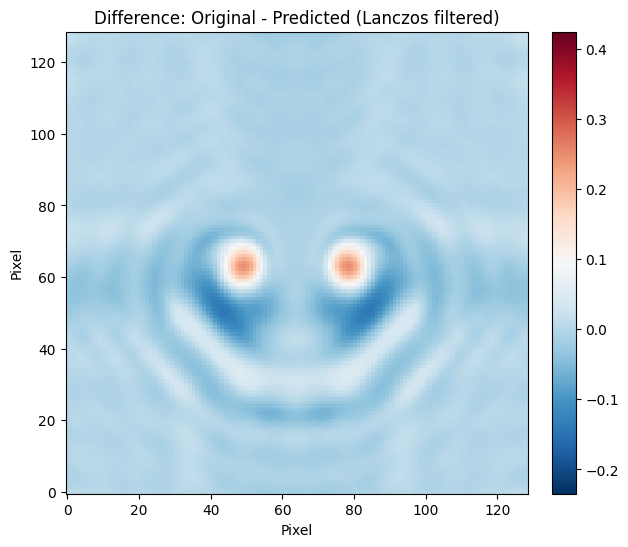

In [28]:
diff_image = true_data[0][50][:, :, 0] - pred_filtered

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.imshow(diff_image, origin='lower', cmap='RdBu_r', vmax=diff_image1.max(), vmin=diff_image1.min())
plt.colorbar(fraction=0.046, pad=0.04)
plt.title('Difference: Original - Predicted (Lanczos filtered)')
plt.xlabel('Pixel')
plt.ylabel('Pixel')
plt.show()

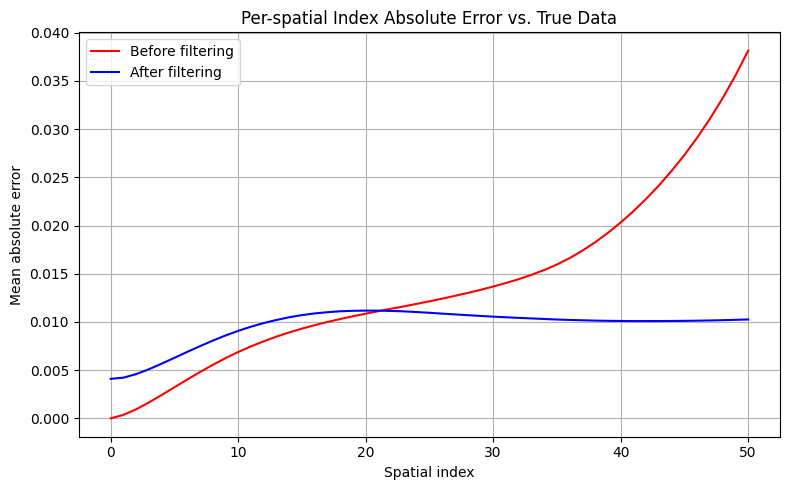

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# Assume: data[0][t][:,:,0] is your predicted frame at timestep t
# Assume: true_data[0][t][:,:,0] is your ground truth frame
# Assume: lanczos_sigma_filter(shape, sigma) is already defined

num_frames = data[0].shape[0]
mae_before = []
mae_after = []

for t in range(num_frames):
    pred = data[0][t][:, :, 0]
    true = true_data[0][t][:, :, 0]

    # --- Absolute error before filtering ---
    err_before = np.abs(pred - true)
    mae_before.append(np.mean(err_before))

    # --- Apply Lanczos filter in Fourier space ---
    f_pred = np.fft.fftshift(np.fft.fft2(pred))
    sigma_mask = lanczos_sigma_filter(pred.shape, 64)
    f_pred_filtered = f_pred * sigma_mask
    pred_filtered = np.real(np.fft.ifft2(np.fft.ifftshift(f_pred_filtered)))

    # --- Absolute error after filtering ---
    err_after = np.abs(pred_filtered - true)
    mae_after.append(np.mean(err_after))

# --- Plot ---
plt.figure(figsize=(8,5))
plt.plot(mae_before, label="Before filtering", color='red')
plt.plot(mae_after, label="After filtering",color='blue')
plt.xlabel("Spatial index")
plt.ylabel("Mean absolute error")
plt.title("Per-spatial Index Absolute Error vs. True Data")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
